In [1]:
import pickle
import torch
from tqdm import tqdm
from minf.data import FieldPDBDataset
from minf.models import Autoencoder, SirenNet, Decoder, SirenNetUnbatched
from minf.utils import plot_field
from torch.utils.data import DataLoader
import numpy as np
import yt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

from rdkit import Chem
from rdkit.Chem import rdMolDescriptors

In [2]:
resolution = 32
rotation = 270

fd = FieldPDBDataset("../data/1osl.pdb", resolution=resolution, single_property=9, subset=[6, 9])
dl = DataLoader(fd, batch_size=1, shuffle=True)
dl_test = DataLoader(fd, batch_size=1, shuffle=False)

yt : [INFO     ] 2025-02-12 23:05:24,818 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:05:24,819 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:05:24,819 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:05:24,819 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:05:24,819 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:05:24,876 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 23:05:24,884 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:05:24,885 Creating volume
yt : [INFO     ] 2025-02-12 23:05:24,901 Creating transfer function
yt : [INFO     ] 2025-02-12 23:05:24,901 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


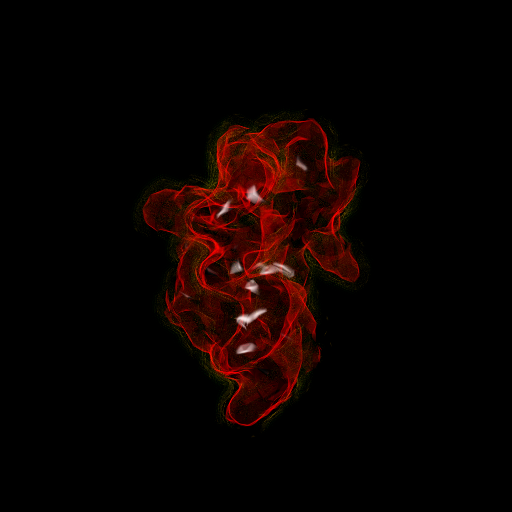

yt : [INFO     ] 2025-02-12 23:05:25,156 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:05:25,156 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:05:25,157 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:05:25,157 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:05:25,157 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:05:25,254 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 23:05:25,261 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:05:25,262 Creating volume
yt : [INFO     ] 2025-02-12 23:05:25,279 Creating transfer function
yt : [INFO     ] 2025-02-12 23:05:25,279 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


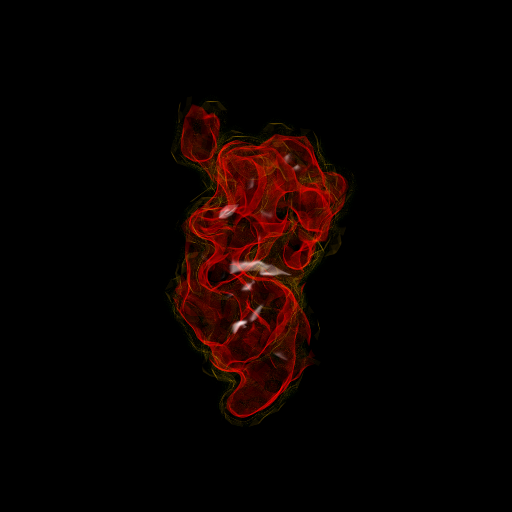

In [3]:
for batch in dl_test:
    for field in batch:
        plot_field(field[:, :, :, 0], cam_rotate=rotation).show()

In [4]:
net = SirenNet(
    dim_in=4,
    dim_hidden=512,
    dim_out=1,
    num_layers=8,
    w0 = 1.0,
    w0_initial = 30.0,
    use_bias = True,
    final_activation = None
)

autoencoder = Autoencoder(
    net,
    in_channels=1,
    output_shape=[resolution, resolution, resolution, 1, 1],
    latent_dim=256,
)

optim = torch.optim.Adam(lr=1e-4, params=autoencoder.parameters())

autoencoder.load_state_dict(torch.load("../models/interpolation.pt", weights_only=True))
autoencoder.cuda()

/home/daenu/micromamba/envs/minf/lib/python3.11/site-packages/torch/functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Autoencoder(
  (net): SirenNet(
    (layers): ModuleList(
      (0-7): 8 x Siren(
        (activation): Sine()
      )
    )
    (last_layer): Siren(
      (activation): Identity()
    )
  )
  (encoder): Encoder(
    (in_layer): Conv3d(1, 2, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_input): BatchNorm3d(2, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (layer_1): Conv3d(2, 4, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_1): BatchNorm3d(4, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (out_layer): Conv3d(4, 256, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (bn_output): BatchNorm3d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (pooling): AdaptiveAvgPool3d(output_size=1)
  )
  (modulator): Modulator(
    (layers): ModuleList(
      (0): Sequential(
        (0): Linear(in_features=256, out_features=512, bias=True)
        (1): ReLU()
      )
      (1-7): 

In [20]:
min_loss = 999999999

for epoch in (pbar := tqdm(range(50000))):
    total_loss = 0
    for batch in dl:
        loss, out, latent = autoencoder(batch.cuda())
        optim.zero_grad()
        loss.backward()
        optim.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(fd)

    if avg_loss < min_loss:
        min_loss = avg_loss
        # torch.save(autoencoder.state_dict(), "interp_2.pt")
    
    pbar.set_description(f"Epoch {epoch} (loss: {avg_loss})")

Epoch 100 (loss: 0.001120936154620722):   0%|▍                                                                                                                                                                                                       | 101/50000 [00:09<1:19:14, 10.50it/s]


KeyboardInterrupt: 

yt : [INFO     ] 2025-02-12 23:05:32,160 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:05:32,160 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:05:32,160 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:05:32,161 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:05:32,161 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:05:32,205 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 23:05:32,212 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:05:32,213 Creating volume
yt : [INFO     ] 2025-02-12 23:05:32,229 Creating transfer function
yt : [INFO     ] 2025-02-12 23:05:32,230 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


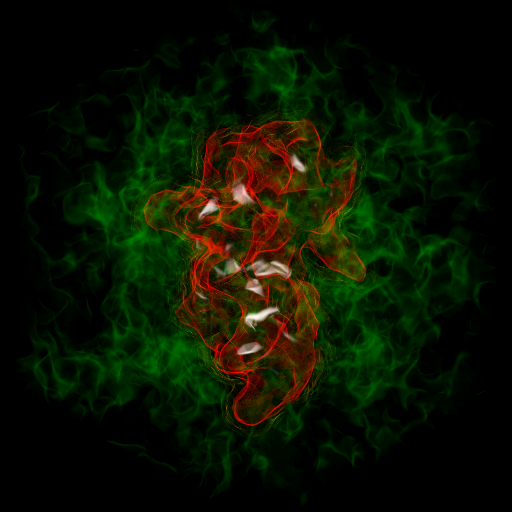

yt : [INFO     ] 2025-02-12 23:05:32,478 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:05:32,478 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:05:32,478 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:05:32,478 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:05:32,479 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:05:32,522 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 23:05:32,528 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:05:32,529 Creating volume
yt : [INFO     ] 2025-02-12 23:05:32,545 Creating transfer function
yt : [INFO     ] 2025-02-12 23:05:32,545 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


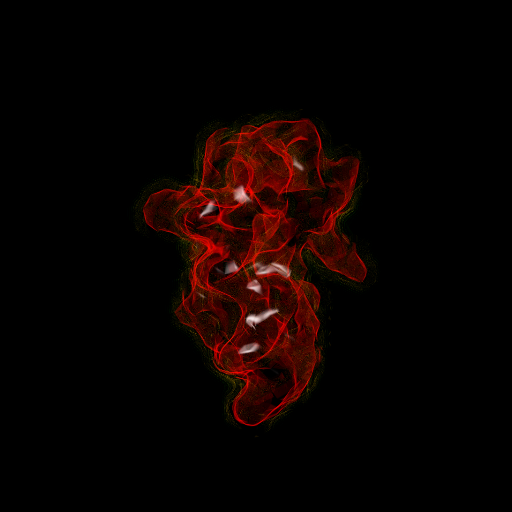

yt : [INFO     ] 2025-02-12 23:05:32,718 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:05:32,718 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:05:32,718 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:05:32,718 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:05:32,718 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:05:32,761 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 23:05:32,767 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:05:32,768 Creating volume
yt : [INFO     ] 2025-02-12 23:05:32,785 Creating transfer function
yt : [INFO     ] 2025-02-12 23:05:32,785 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


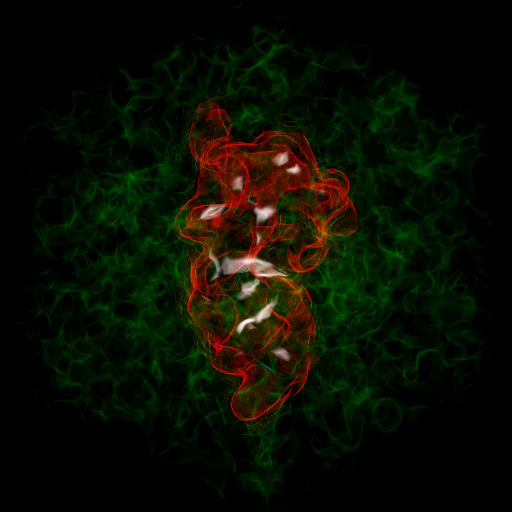

yt : [INFO     ] 2025-02-12 23:05:33,038 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:05:33,039 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:05:33,039 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:05:33,039 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:05:33,039 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:05:33,082 Setting default field to ('gas', 'density')
yt : [INFO     ] 2025-02-12 23:05:33,088 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:05:33,089 Creating volume
yt : [INFO     ] 2025-02-12 23:05:33,105 Creating transfer function
yt : [INFO     ] 2025-02-12 23:05:33,105 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


gt


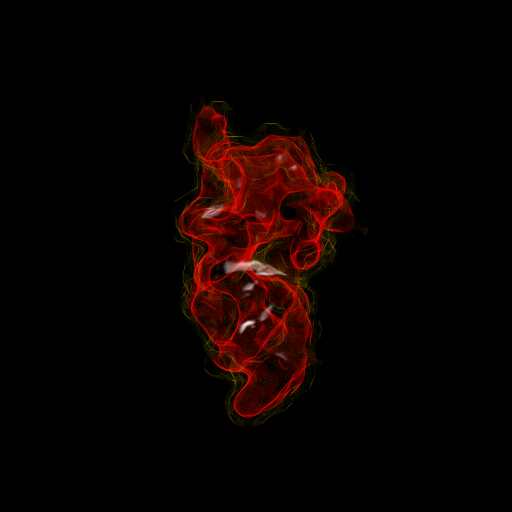

In [5]:
i = 0
for batch in dl_test:
    latent = autoencoder.encode(batch.cuda())
    reconstructed = autoencoder.predict(latent).cpu().detach()
    
    for r in reconstructed:
        plot_field(r.flatten(3)[:, :, :, 0]).show()
        print("gt")
        plot_field(fd[i][:, :, :, 0]).show()
        i += 1

In [6]:
def interp(arr1, arr2, num_points):
    fractions = np.linspace(0, 1, num_points)
    return np.array([arr1 + (arr2 - arr1) * f for f in fractions])

In [13]:
latents = []

for batch in dl_test:
    lats = autoencoder.encode(batch.cuda())
    for lat in lats:
        latents.append(lat.cpu().detach())

latents_intrp = interp(latents[0], latents[1], 200)
print(latents_intrp.shape, latents[0].shape)
for i, l in enumerate(latents_intrp):
    reconstructed = autoencoder.predict(torch.FloatTensor(np.array([l])).cuda())[0]
    reconstructed = reconstructed.cpu().detach().squeeze(-1)
    f = reconstructed.flatten(3)[:, :, :, 0]
    f[f < 0.00001] = 0
    plot_field(f).save(f"{i:05d}.png")

yt : [INFO     ] 2025-02-12 23:14:25,472 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:14:25,473 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:14:25,473 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:14:25,473 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:14:25,473 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:14:25,516 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-12 23:14:25,522 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-12 23:14:25,522 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:14:25,523 Creating volume
yt : [INFO     ] 2025-02-12 23:14:25,539 Creating transfer function
yt : [INFO     ] 2025-02-12 23:14:25,539 Calculating data bounds. This may take a while. Set the TransferFunctionHelper.bounds to avoid this.


(200, 256) torch.Size([256])


yt : [INFO     ] 2025-02-12 23:14:25,684 Saving rendered image to 00000.png
yt : [INFO     ] 2025-02-12 23:14:25,774 Parameters: current_time              = 0.0
yt : [INFO     ] 2025-02-12 23:14:25,774 Parameters: domain_dimensions         = [32 32 32]
yt : [INFO     ] 2025-02-12 23:14:25,775 Parameters: domain_left_edge          = [0. 0. 0.]
yt : [INFO     ] 2025-02-12 23:14:25,775 Parameters: domain_right_edge         = [1. 1. 1.]
yt : [INFO     ] 2025-02-12 23:14:25,775 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2025-02-12 23:14:25,817 Setting default field to ('gas', 'density')
yt : [WARNING  ] 2025-02-12 23:14:25,823 No previously rendered image found, rendering now.
yt : [INFO     ] 2025-02-12 23:14:25,824 Rendering scene (Can take a while).
yt : [INFO     ] 2025-02-12 23:14:25,824 Creating volume
yt : [INFO     ] 2025-02-12 23:14:25,840 Creating transfer function
yt : [INFO     ] 2025-02-12 23:14:25,841 Calculating data bounds. This may take a while. Set the Tran